
# A2a Addendum — Trivial-Baseline Control for Probe 2 (H1 vs. H3)

**Purpose.** A2a's Probe 2 found that Burgers ν=1.0 is the *only* class
where Panda's own MAE **improves** as context length shrinks (512→32);
every other class gets worse. That asymmetry is scale-free (a direction,
not a magnitude), so it survives the scale-confound problem that undermined
Probe 1's gate. But it is still ambiguous between two explanations:

- **H1 (attention-mechanism):** Panda's temporal attention makes
  differential use of long-range order depending on class — a genuine
  architectural finding, and the strongest remaining evidence for
  escalating to A2b.
- **H3 (intrinsic-predictability confound):** Burgers ν=1.0 is a smooth,
  strongly diffusive PDE with short effective memory. A context-length
  asymmetry could be a property of *the data*, present for any predictor,
  transformer or not — in which case Probe 2 says nothing about Panda's
  attention mechanism specifically.

**This notebook adjudicates by running the same context-length sweep with
non-learned baselines** (persistence, linear extrapolation, context-mean)
against the exact same Burgers ν=1.0 trajectories used in A2a, plus Lorenz
as a chaotic-system control. No model, no GPU, no Kaggle — pure numpy/scipy,
runs on the CPU laptop in under a minute.

**Interpretation logic (fixed before running):**
- If a trivial baseline **also** shows MAE improving as context shrinks on
  Burgers, that pattern is a data property — H3 gains support, and Probe
  2's contribution to the A2b escalation case is weakened (it would be
  double-counting an artifact already partly visible in Probe 1's scale
  confound).
- If trivial baselines are flat or **worsen** with shorter context on
  Burgers (unlike Panda), that dissociation is real evidence Panda's
  attention is doing something class-specific — strengthening H1
  independent of Probe 1's scale problem.
- Lorenz is included as a control: chaotic systems should NOT show the
  "less context helps" pattern for any baseline, trivial or not. If they
  don't, that's a sanity check that the sweep itself is well-posed.

Constants (`CONTEXT_LEN`, `HORIZONS`, `N_WINDOWS`, `TRUNCATION_LENGTHS`,
seeds) are copied verbatim from `a2a_temporal_attention_probes.ipynb` Cells
4b/7/10 for exact window-for-window comparability with Panda's own Probe 2
numbers. This is deliberately NOT a new pre-registered gate on A2b — it's a
diagnostic to weight how much Probe 2 should count as supporting evidence,
per the project's OBS/PAT/HYP discipline.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from scipy.linalg import svd

# ---- shared constants, verbatim from a2a_temporal_attention_probes.ipynb Cell 4b ----
CONTEXT_LEN = 512
HORIZONS = [96, 192, 336]
N_WINDOWS = 20
TRUNCATION_LENGTHS = [512, 256, 128, 64, 32]
TRANSIENT_DISCARD = 500  # matches A1/A2a convention


In [2]:
# ---- Burgers nu=1.0 simulator + PCA reduction, verbatim from A2a Cell 7 ----

def simulate_burgers_stable(T=1000, N_x=128, nu=0.005, seed=0):
    rng = np.random.default_rng(seed)
    dx  = 2 * np.pi / N_x
    dt_diff   = 0.4 * dx**2 / (2 * nu + 1e-10)
    dt_adv    = 0.4 * dx
    dt        = min(dt_diff, dt_adv, 0.05)
    dt_record = 0.01
    n_sub     = max(1, int(np.ceil(dt_record / dt)))
    dt_act    = dt_record / n_sub
    k       = fftfreq(N_x, d=1.0/N_x).astype(complex)
    dealias = np.abs(k) <= N_x // 3
    L_op    = -nu * k**2
    u0_hat = np.zeros(N_x, dtype=complex)
    for m in range(1, 6):
        amp = rng.standard_normal() + 1j * rng.standard_normal()
        u0_hat[m]       += amp
        u0_hat[N_x - m] += np.conj(amp)
    u0_hat *= dealias
    def rhs_hat(u_hat):
        u_phys = np.real(ifft(u_hat))
        nonlin = fft(0.5 * u_phys**2) * dealias
        return L_op * u_hat - 1j * k * nonlin
    U     = np.zeros((T, N_x), dtype=np.float32)
    u_hat = u0_hat.copy()
    for t in range(T):
        U[t] = np.real(ifft(u_hat)).astype(np.float32)
        for _ in range(n_sub):
            k1    = rhs_hat(u_hat)
            k2    = rhs_hat(u_hat + 0.5*dt_act*k1)
            k3    = rhs_hat(u_hat + 0.5*dt_act*k2)
            k4    = rhs_hat(u_hat +     dt_act*k3)
            u_hat = u_hat + (dt_act/6.0)*(k1+2*k2+2*k3+k4)
            u_hat *= dealias
            if not np.isfinite(u_hat).all():
                return U[:t]
    return U  # (T, N_x)

def pca_reduction(U, n_components):
    U_c  = U - U.mean(axis=0, keepdims=True)
    n_c  = min(n_components, min(U_c.shape)-1)
    _, _, Vt = svd(U_c, full_matrices=False)
    return (U_c @ Vt[:n_c].T).astype(np.float32)  # (T, n_components)

def load_burgers_nu1_trajectories(n_traj, length=512, seed=0):
    trajs = []
    for i in range(n_traj):
        U = simulate_burgers_stable(T=length, N_x=128, nu=1.0, seed=seed + i)
        if U.shape[0] < length:
            raise RuntimeError(f'Burgers trajectory {i} diverged before reaching required length '
                                f'({U.shape[0]} < {length}) -- investigate seed={seed+i}.')
        pca_series = pca_reduction(U, 16)  # (length, 16) -- all 16 kept, matches A1/A2a
        trajs.append(pca_series)
    return trajs


# ---- Lorenz gate_3ch simulator, verbatim from A2a Cell 7 (chaotic control) ----

def simulate_lorenz_gate(n=5000, dt=0.01, sigma=10, rho=28, beta=8/3):
    x, y, z = 0.1, 0.0, 0.0
    xs, ys, zs = [x], [y], [z]
    for _ in range(n - 1):
        k1x = sigma * (y - x); k1y = x * (rho - z) - y; k1z = x * y - beta * z
        k2x = sigma * ((y + dt/2*k1y) - (x + dt/2*k1x))
        k2y = (x + dt/2*k1x) * (rho - (z + dt/2*k1z)) - (y + dt/2*k1y)
        k2z = (x + dt/2*k1x) * (y + dt/2*k1y) - beta * (z + dt/2*k1z)
        k3x = sigma * ((y + dt/2*k2y) - (x + dt/2*k2x))
        k3y = (x + dt/2*k2x) * (rho - (z + dt/2*k2z)) - (y + dt/2*k2y)
        k3z = (x + dt/2*k2x) * (y + dt/2*k2y) - beta * (z + dt/2*k2z)
        k4x = sigma * ((y + dt*k3y) - (x + dt*k3x))
        k4y = (x + dt*k3x) * (rho - (z + dt*k3z)) - (y + dt*k3y)
        k4z = (x + dt*k3x) * (y + dt*k3y) - beta * (z + dt*k3z)
        x += dt/6*(k1x+2*k2x+2*k3x+k4x)
        y += dt/6*(k1y+2*k2y+2*k3y+k4y)
        z += dt/6*(k1z+2*k2z+2*k3z+k4z)
        xs.append(x); ys.append(y); zs.append(z)
    return np.array([xs, ys, zs]).T  # (n, 3)

def load_lorenz_trajectories(n_traj, length=512, seed=0):
    # NOTE: fixed IC, single deterministic orbit, non-overlapping slices --
    # same documented limitation as A1/A2a, not fixed here (kept identical
    # for exact comparability with Panda's own Probe 2 Lorenz numbers).
    n_needed = TRANSIENT_DISCARD + n_traj * length
    full = simulate_lorenz_gate(n=n_needed, dt=0.01)
    full = full[TRANSIENT_DISCARD:]
    trajs = [full[i*length:(i+1)*length] for i in range(n_traj)]
    return trajs


TRAJ_LOADERS = {'burgers': load_burgers_nu1_trajectories, 'lorenz': load_lorenz_trajectories}

def get_context_target_windows(class_name, horizon, n_windows=N_WINDOWS, seed=0):
    loader = TRAJ_LOADERS[class_name]
    length = CONTEXT_LEN + horizon
    raw_trajs = loader(n_traj=n_windows, length=length, seed=seed)
    windows = [(traj[:CONTEXT_LEN], traj[CONTEXT_LEN:CONTEXT_LEN + horizon]) for traj in raw_trajs]
    return windows

print('Simulators loaded (verbatim from A2a). Classes:', list(TRAJ_LOADERS.keys()))


Simulators loaded (verbatim from A2a). Classes: ['burgers', 'lorenz']


## Trivial baselines

**Design note (caught by a smoke test before this notebook was finalized):**
the truncation sweep truncates context *from the front*
(`context[-ctx_len:]`) — it always keeps the most recent points. A baseline
that only reads the last `k` points (plain persistence, or a linear fit to
a fixed short tail) is therefore structurally blind to `context_len`: it
returns bit-identical predictions regardless of how much context was cut,
since the part it looks at never changes. That would produce an
uninformative flat/undefined correlation that looks like "no effect" but
is actually just a baseline that can't see the manipulation at all.

Two baselines below are kept anyway *as a documented negative control* —
they are expected to show ~zero context-length sensitivity by construction,
not because that says anything about Burgers. The three that can actually
speak to H1 vs. H3 are the ones that use the **entire** available truncated
context:

- **persistence** (control, expected flat) — repeat the last value.
- **tail_linear** (control, expected flat) — line fit to a fixed last-10
  points.
- **full_context_linear** — line fit to *all* points in the truncated
  context, extrapolated forward. Genuinely sensitive to context_len.
- **context_mean** — mean of the entire truncated context. Genuinely
  sensitive to context_len.
- **ar5_ridge** — a ridge-regularized order-5 autoregressive model, fit by
  least squares on all consecutive lag-5 windows within the truncated
  context, then rolled forward autoregressively. No attention, no
  positional encoding beyond 5 lags — but its fit quality depends directly
  on how much context data it had to estimate the AR coefficients from,
  making it the closest cheap analog to "does more history help."


In [3]:
def persistence_baseline(context, horizon):
    last = context[-1:]  # (1, C)
    return np.repeat(last, horizon, axis=0)

def tail_linear_baseline(context, horizon, k=10):
    T, C = context.shape
    k = min(k, T)
    tail = context[-k:]
    xs = np.arange(k)
    future_xs = np.arange(k, k + horizon)
    preds = np.zeros((horizon, C), dtype=np.float64)
    for c in range(C):
        slope, intercept = np.polyfit(xs, tail[:, c], 1)
        preds[:, c] = slope * future_xs + intercept
    return preds

def full_context_linear_baseline(context, horizon):
    T, C = context.shape
    xs = np.arange(T)
    future_xs = np.arange(T, T + horizon)
    preds = np.zeros((horizon, C), dtype=np.float64)
    for c in range(C):
        slope, intercept = np.polyfit(xs, context[:, c], 1)
        preds[:, c] = slope * future_xs + intercept
    return preds

def mean_baseline(context, horizon):
    m = context.mean(axis=0, keepdims=True)
    return np.repeat(m, horizon, axis=0)

def ar5_ridge_baseline(context, horizon, order=5, ridge=1e-3):
    T, C = context.shape
    order = min(order, max(1, T - 1))
    preds = np.zeros((horizon, C), dtype=np.float64)
    for c in range(C):
        series = context[:, c].astype(np.float64)
        n_rows = T - order
        if n_rows < 2:
            preds[:, c] = series[-1]
            continue
        X = np.stack([series[i:i + order] for i in range(n_rows)], axis=0)  # (n_rows, order)
        y = series[order:]  # (n_rows,)
        A = X.T @ X + ridge * np.eye(order)
        b = X.T @ y
        coef = np.linalg.solve(A, b)
        history = list(series[-order:])
        for h in range(horizon):
            pred = float(np.dot(coef, history[-order:]))
            preds[h, c] = pred
            history.append(pred)
    return preds

BASELINES = {
    'persistence': persistence_baseline,          # control, expect flat
    'tail_linear': tail_linear_baseline,           # control, expect flat
    'full_context_linear': full_context_linear_baseline,  # context-sensitive
    'context_mean': mean_baseline,                 # context-sensitive
    'ar5_ridge': ar5_ridge_baseline,                # context-sensitive
}


In [4]:
# ---- truncation sweep, trivial baselines only, Burgers + Lorenz ----

results = []
for class_name in TRAJ_LOADERS:
    for horizon in HORIZONS:
        windows = get_context_target_windows(class_name, horizon)
        for ctx_len in TRUNCATION_LENGTHS:
            per_baseline_maes = {name: [] for name in BASELINES}
            for context, target in windows:
                truncated = context[-ctx_len:]
                for name, fn in BASELINES.items():
                    pred = fn(truncated, horizon)
                    mae = np.mean(np.abs(pred - target))
                    per_baseline_maes[name].append(mae)
            for name, maes in per_baseline_maes.items():
                results.append({
                    'class': class_name, 'baseline': name, 'horizon': horizon,
                    'context_len': ctx_len, 'mae_median': float(np.median(maes)),
                    'mae_iqr': float(np.percentile(maes, 75) - np.percentile(maes, 25)),
                })

baseline_df = pd.DataFrame(results)
baseline_df.to_csv('a2a_addendum_baseline_truncation_results.csv', index=False)
baseline_df.head(10)


,class,baseline,horizon,context_len,mae_median,mae_iqr
0,burgers,persistence,96,512,0.000032,0.000013
1,burgers,tail_linear,96,512,0.000013,0.000005
2,burgers,full_context_linear,96,512,0.003118,0.001114
3,burgers,context_mean,96,512,0.002541,0.001101
4,burgers,ar5_ridge,96,512,0.001345,0.000308
5,burgers,persistence,96,256,0.000032,0.000013
6,burgers,tail_linear,96,256,0.000013,0.000005
7,burgers,full_context_linear,96,256,0.000305,0.000124
8,burgers,context_mean,96,256,0.000359,0.000147
9,burgers,ar5_ridge,96,256,0.000341,0.000139


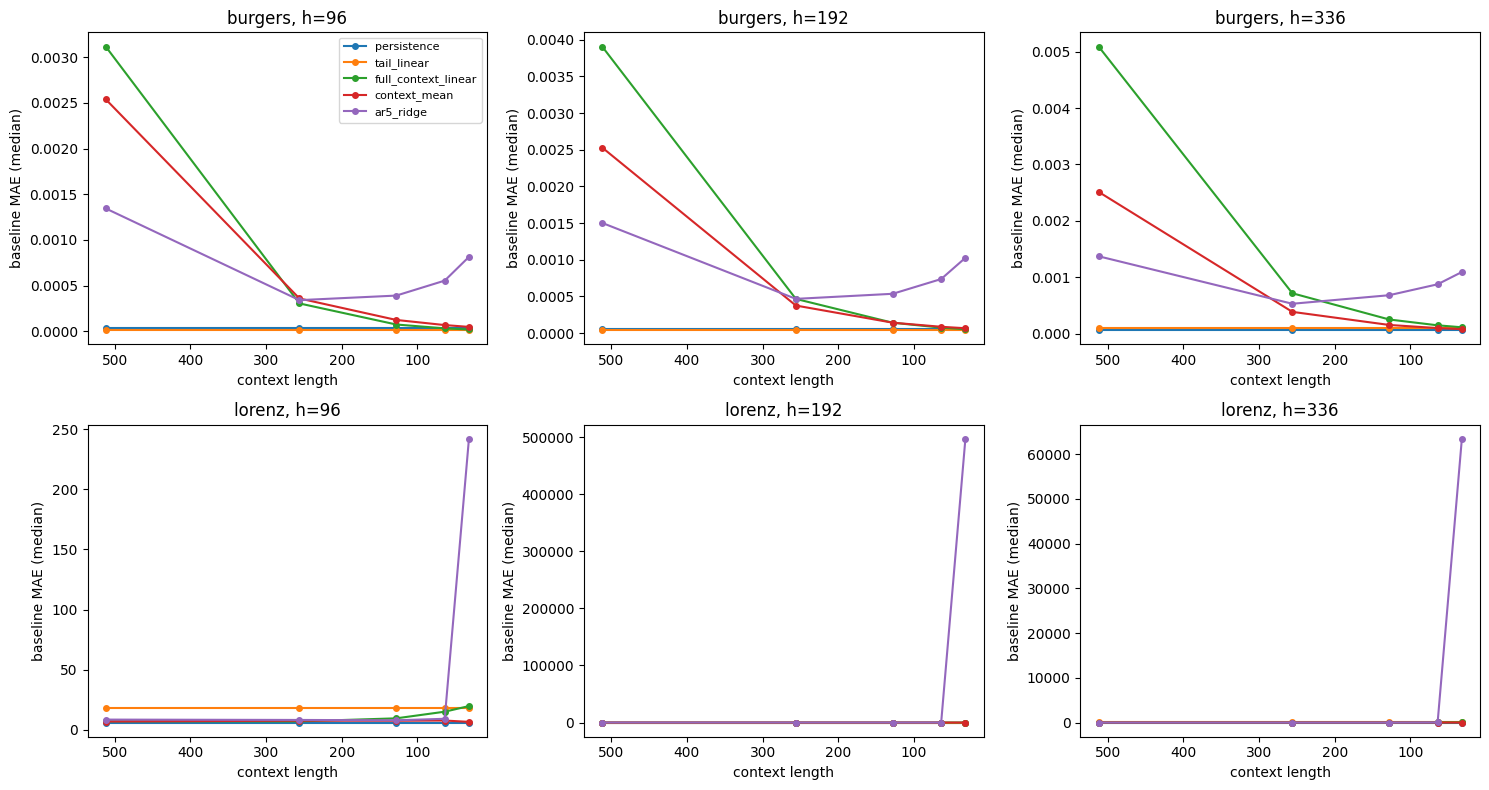

In [5]:
# ---- plot: baseline MAE vs context length, one panel per (class, horizon) ----

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False)
for row, class_name in enumerate(['burgers', 'lorenz']):
    for col, horizon in enumerate(HORIZONS):
        ax = axes[row, col]
        for name in BASELINES:
            sub = baseline_df[(baseline_df['class'] == class_name) &
                               (baseline_df.baseline == name) &
                               (baseline_df.horizon == horizon)].sort_values('context_len')
            ax.plot(sub.context_len, sub.mae_median, '-o', label=name, markersize=4)
        ax.set_title(f'{class_name}, h={horizon}')
        ax.set_xlabel('context length')
        ax.set_ylabel('baseline MAE (median)')
        ax.invert_xaxis()
        if row == 0 and col == 0:
            ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('a2a_addendum_baseline_truncation_curves.png', dpi=150)
plt.show()


## Auto-computed interpretation

For each (class, baseline, horizon), compute the Spearman correlation
between `context_len` and `mae_median` across the 5 truncation points.

- **Positive correlation** (longer context → higher baseline MAE) matches
  the direction Panda itself showed on Burgers in A2a Probe 2 — i.e. the
  trivial baseline reproduces Panda's asymmetry, supporting **H3**.
- **Zero / negative correlation** (baseline flat or behaves normally,
  getting worse with less context) means the trivial baseline does *not*
  reproduce Panda's pattern — supporting **H1**, since the asymmetry would
  then be something Panda's architecture is doing, not a property of the
  data any predictor would pick up on.

This is descriptive, not a formal gate — report the correlations plainly
before drawing a conclusion, per the project's standing discipline of not
letting interpretation slide ahead of the numbers.


In [6]:
from scipy.stats import spearmanr

corr_rows = []
for class_name in TRAJ_LOADERS:
    for name in BASELINES:
        for horizon in HORIZONS:
            sub = baseline_df[(baseline_df['class'] == class_name) &
                               (baseline_df.baseline == name) &
                               (baseline_df.horizon == horizon)].sort_values('context_len')
            rho, p = spearmanr(sub.context_len, sub.mae_median)
            corr_rows.append({'class': class_name, 'baseline': name, 'horizon': horizon,
                               'spearman_rho': rho, 'p_value': p})

corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv('a2a_addendum_correlation_summary.csv', index=False)
print(corr_df.pivot_table(index=['class', 'baseline'], columns='horizon', values='spearman_rho').round(3))
print()
print('Reminder: Panda baseline_100k on Burgers (A2a Probe 2) showed context_len vs MAE')
print('correlation that is POSITIVE across all 3 horizons (more context -> worse MAE).')
print('Compare the burgers rows above against that sign, per baseline, per horizon.')
print('Lorenz rows are the control: chaotic systems should show negative correlation')
print('(more context -> better MAE), matching Panda\'s own Lorenz behaviour in Probe 2.')


C:\Users\user\AppData\Local\Temp\ipykernel_9572\2509003731.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(sub.context_len, sub.mae_median)


horizon                      96   192  336
class   baseline                          
burgers ar5_ridge            0.0  0.0  0.0
        context_mean         1.0  1.0  1.0
        full_context_linear  1.0  1.0  1.0
lorenz  ar5_ridge           -0.6 -0.3 -0.6
        context_mean         0.1 -0.6 -0.9
        full_context_linear -0.9 -1.0 -1.0

Reminder: Panda baseline_100k on Burgers (A2a Probe 2) showed context_len vs MAE
correlation that is POSITIVE across all 3 horizons (more context -> worse MAE).
Compare the burgers rows above against that sign, per baseline, per horizon.
Lorenz rows are the control: chaotic systems should show negative correlation
(more context -> better MAE), matching Panda's own Lorenz behaviour in Probe 2.


## Next steps

- Read the correlation table plainly (sign and magnitude, all 3 baselines,
  all 3 horizons) before deciding what it means for H1 vs. H3 — resist the
  pull to pick whichever baseline's correlation supports the preferred
  story.
- Bring the CSV outputs (`a2a_addendum_baseline_truncation_results.csv`,
  `a2a_addendum_correlation_summary.csv`) and the plot back to the main
  thread for a joint OBS/PAT/HYP writeup alongside A2a Probes 1–3, as part
  of the same Experiment 37+ log entry rather than a separate one — this is
  an addendum to A2a's evidence base, not a new standalone experiment.
- This notebook does not itself decide A2b escalation — Probe 1's
  pre-registered gate already produced a mechanical verdict (ESCALATE, with
  the scale-confound caveat noted). What this notebook does is tell you how
  much weight Probe 2's asymmetry should carry in the qualitative case for
  or against trusting that verdict.
